In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import mpl_toolkits
import mplhep
import seaborn as sb

In [2]:
def load_benchmark_json(path: str, merge_index: bool = False) -> pd.DataFrame:
    with open(path) as f:
        data = json.load(f)

    rows = []
    for b in data["benchmarks"]:
        row = {
            "name": b["name"],
            "file_type": b["params"]["file_type"],
            "num_events": b["params"]["num_events"],
            "test_method": b["params"]["test_method"],
            "column_mode": b["params"]["column_mode"],
            "file_percentage": b["params"]["file_percentage"],
            "mean_time": b["stats"]["mean"],
            "median_time": b["stats"]["median"],
            "min_time": b["stats"]["min"],
            "max_time": b["stats"]["max"],
            "stddev": b["stats"]["stddev"],
            "rounds": b["stats"]["rounds"],
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    if merge_index:
        df = df.set_index(["file_type", "column_mode", "file_percentage", "num_events"]).sort_index()
    return df

In [3]:
df1 = load_benchmark_json(  # Adjust path as needed
    "/work/kschmidt/NEEDLE/orchestrator/.benchmarks/Linux-CPython-3.12-64bit/0036_8551e6b0177cfb1fd164b5ba0943951ddb08af0b_20260220_132556.json",
)
df2 = load_benchmark_json(
    "/work/kschmidt/NEEDLE/orchestrator/.benchmarks/Linux-CPython-3.12-64bit/0037_8551e6b0177cfb1fd164b5ba0943951ddb08af0b_20260220_142953.json",
)
df = pd.concat([df1, df2]) # test run

FileNotFoundError: [Errno 2] No such file or directory: '/work/kschmidt/NEEDLE/orchestrator/.benchmarks/Linux-CPython-3.12-64bit/0036_8551e6b0177cfb1fd164b5ba0943951ddb08af0b_20260220_132556.json'

In [4]:
df = load_benchmark_json(
    "/work/kschmidt/NEEDLE/orchestrator/.benchmarks/Linux-CPython-3.12-64bit/interesting_runs/0038_8551e6b0177cfb1fd164b5ba0943951ddb08af0b_20260220_150438.json"
)  # full run

In [5]:
df

,name,file_type,num_events,test_method,column_mode,file_percentage,mean_time,median_time,min_time,max_time,stddev,rounds
0,test_ingestion_speed[only_metadata-root-events...,root,-1,only_metadata,one,0.1,117.353489,116.808277,105.745026,131.899552,10.069579,5
1,test_ingestion_speed[only_metadata-root-events...,root,-1,only_metadata,config,0.1,120.164414,119.481773,78.859320,161.134826,29.965190,5
2,test_ingestion_speed[only_metadata-parquet-eve...,parquet,-1,only_metadata,one,0.1,1.089904,1.090213,1.081538,1.097797,0.006133,5
3,test_ingestion_speed[only_metadata-parquet-eve...,parquet,-1,only_metadata,config,0.1,1.072315,1.071342,1.069080,1.080172,0.004551,5
4,test_ingestion_speed[materialize_partitions-ro...,root,-1,materialize_partitions,one,0.1,133.870387,113.185682,103.151173,178.420499,35.914116,5
5,test_ingestion_speed[materialize_partitions-ro...,root,-1,materialize_partitions,config,0.1,152.169247,155.399906,139.941847,161.240631,8.583786,5
6,test_ingestion_speed[materialize_partitions-pa...,parquet,-1,materialize_partitions,one,0.1,2.335947,2.335579,2.312225,2.366330,0.023379,5
7,test_ingestion_speed[materialize_partitions-pa...,parquet,-1,materialize_partitions,config,0.1,10.679025,10.644249,10.538452,10.890125,0.129333,5
8,test_ingestion_speed[iterate_dataloader-root-e...,root,-1,iterate_dataloader,one,0.1,194.602288,240.116635,60.698391,323.181297,114.955545,5
9,test_ingestion_speed[iterate_dataloader-root-e...,root,-1,iterate_dataloader,config,0.1,457.914841,546.464705,214.558902,704.965606,208.953812,5


In [14]:
# Plot ingestion time root vs. parquet

df_filtered = df[
    (df["column_mode"] == "config") &
    (df["test_method"].isin(["only_metadata", "materialize_partitions", "iterate_dataloader"]))
]
grouped = df_filtered.groupby(["file_type", "test_method"])["mean_time"].mean().unstack()
df_errors = df_filtered.groupby(["file_type", "test_method"])["stddev"].mean().unstack()

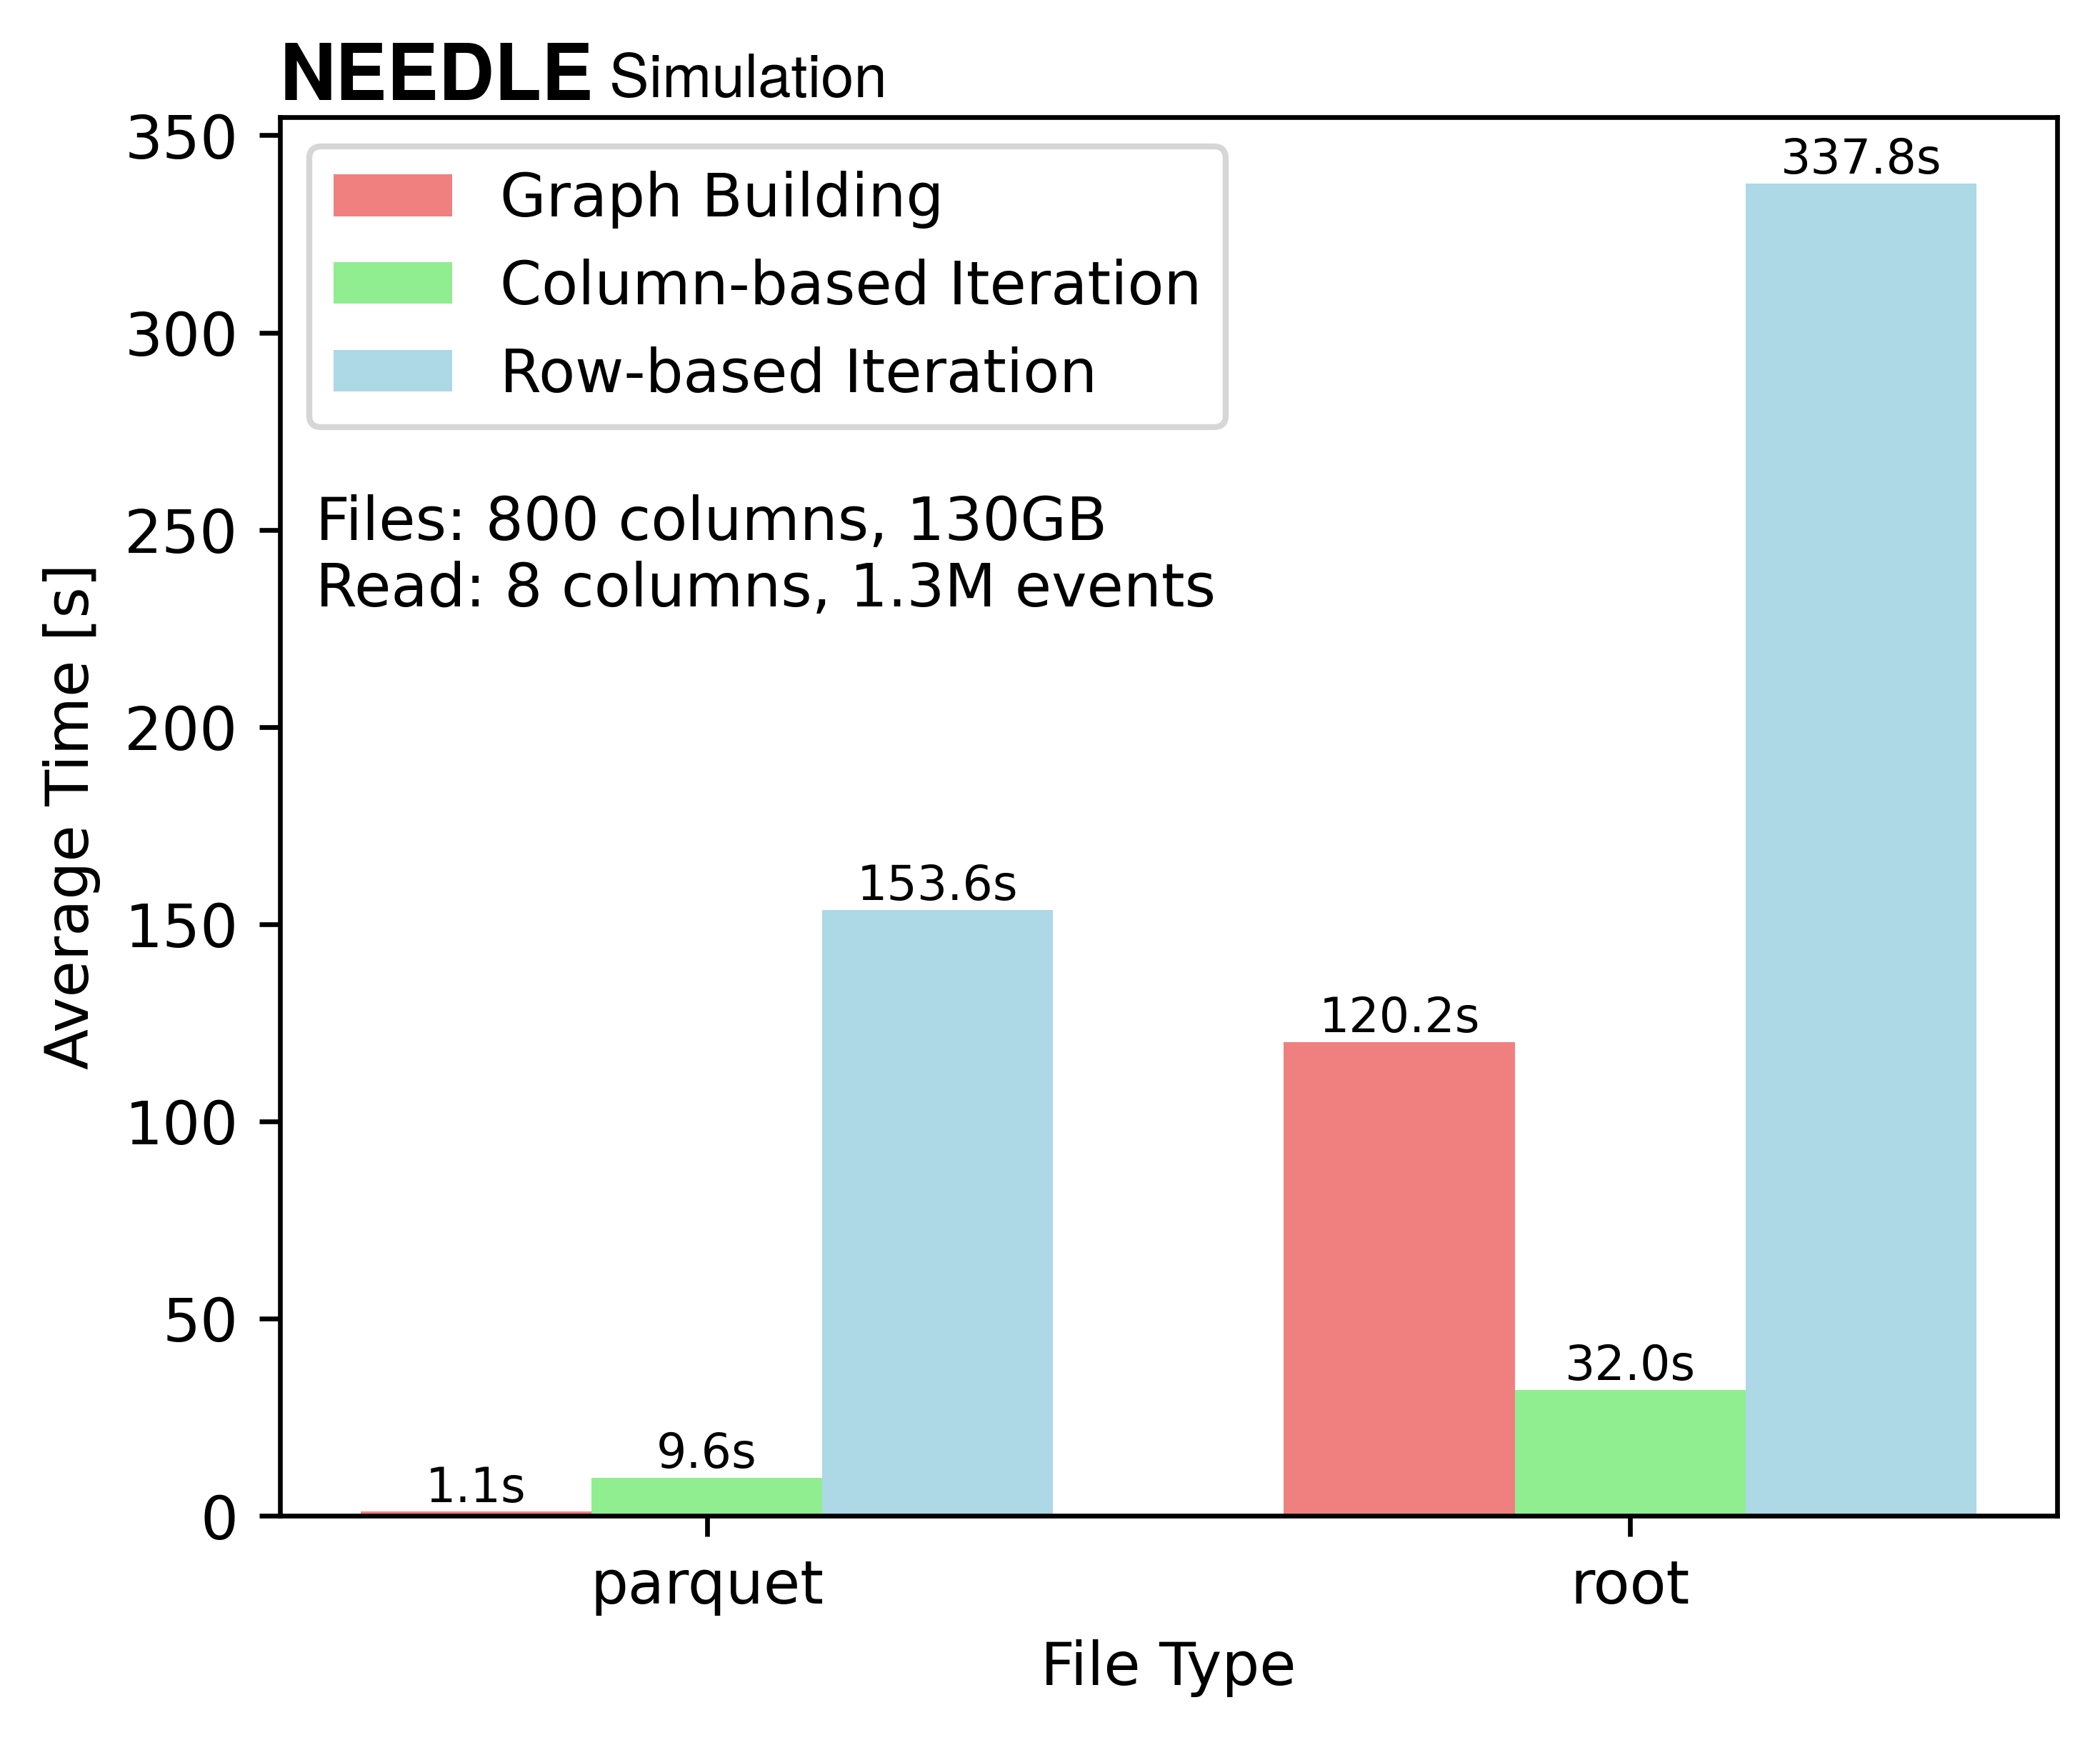

In [47]:
import numpy as np

file_types = ["parquet", "root"]
components = ["Graph Building", "Column-based Iteration", "Row-based Iteration"]
methods = ["only_metadata", "materialize_partitions", "iterate_dataloader"]
colors = ["lightcoral", "lightgreen", "lightblue"]

times = {}
for ft in file_types:
    graph_building = grouped.loc[ft, "only_metadata"]
    materialization = grouped.loc[ft, "materialize_partitions"] - graph_building
    total = grouped.loc[ft, "iterate_dataloader"] - graph_building
    times[ft] = [graph_building, materialization, total]

# errors = {}
# for ft in file_types:
#     graph_building = df_errors.loc[ft, "only_metadata"]
#     materialization = df_errors.loc[ft, "materialize_partitions"] -
#     total = df_errors.loc[ft, "iterate_dataloader"]
#     errors[ft] = [graph_building, materialization, total]

x = np.arange(len(file_types))
width = 0.25

fig, ax = plt.subplots(figsize=(5, 4), dpi=600)
for i, comp in enumerate(components):
    # Plot bars
    ax.bar(
        x + i * width,
        [times[ft][i] for ft in file_types],
        width,
        label=comp,
        color=colors[i],
        alpha=1,
        zorder=2,
        # yerr=[errors[ft][i] for ft in file_types],
    )
    # Add value labels
    for j, ft in enumerate(file_types):
        bar_x = x[j] + i * width
        bar_height = times[ft][i]
        unit = "ms" if bar_height < 1 else "s"
        value = bar_height * 1000 if unit == "ms" else bar_height
        ax.text(bar_x, bar_height + 0.01, f"{value:.1f}{unit}", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("File Type")
ax.set_ylabel("Average Time [s]")
ax.set_xticks(x + width)
ax.set_xticklabels(file_types)
ax.legend(loc="upper left")
ax.text(
    0.02,
    0.65,
    s="Files: 800 columns, 130GB\n"
    f"Read: {8} columns, 1.3M events",
    transform=ax.transAxes,
    fontsize=10,
)
plt.tight_layout()
plt.savefig("/home/kschmidt/Documents/NEEDLE/plots/benchmarks/root_vs_parquet.png")
mplhep.label.exp_label(
    loc=0,
    exp="NEEDLE",
    ax=ax,
    rlabel="",
)
plt.show()

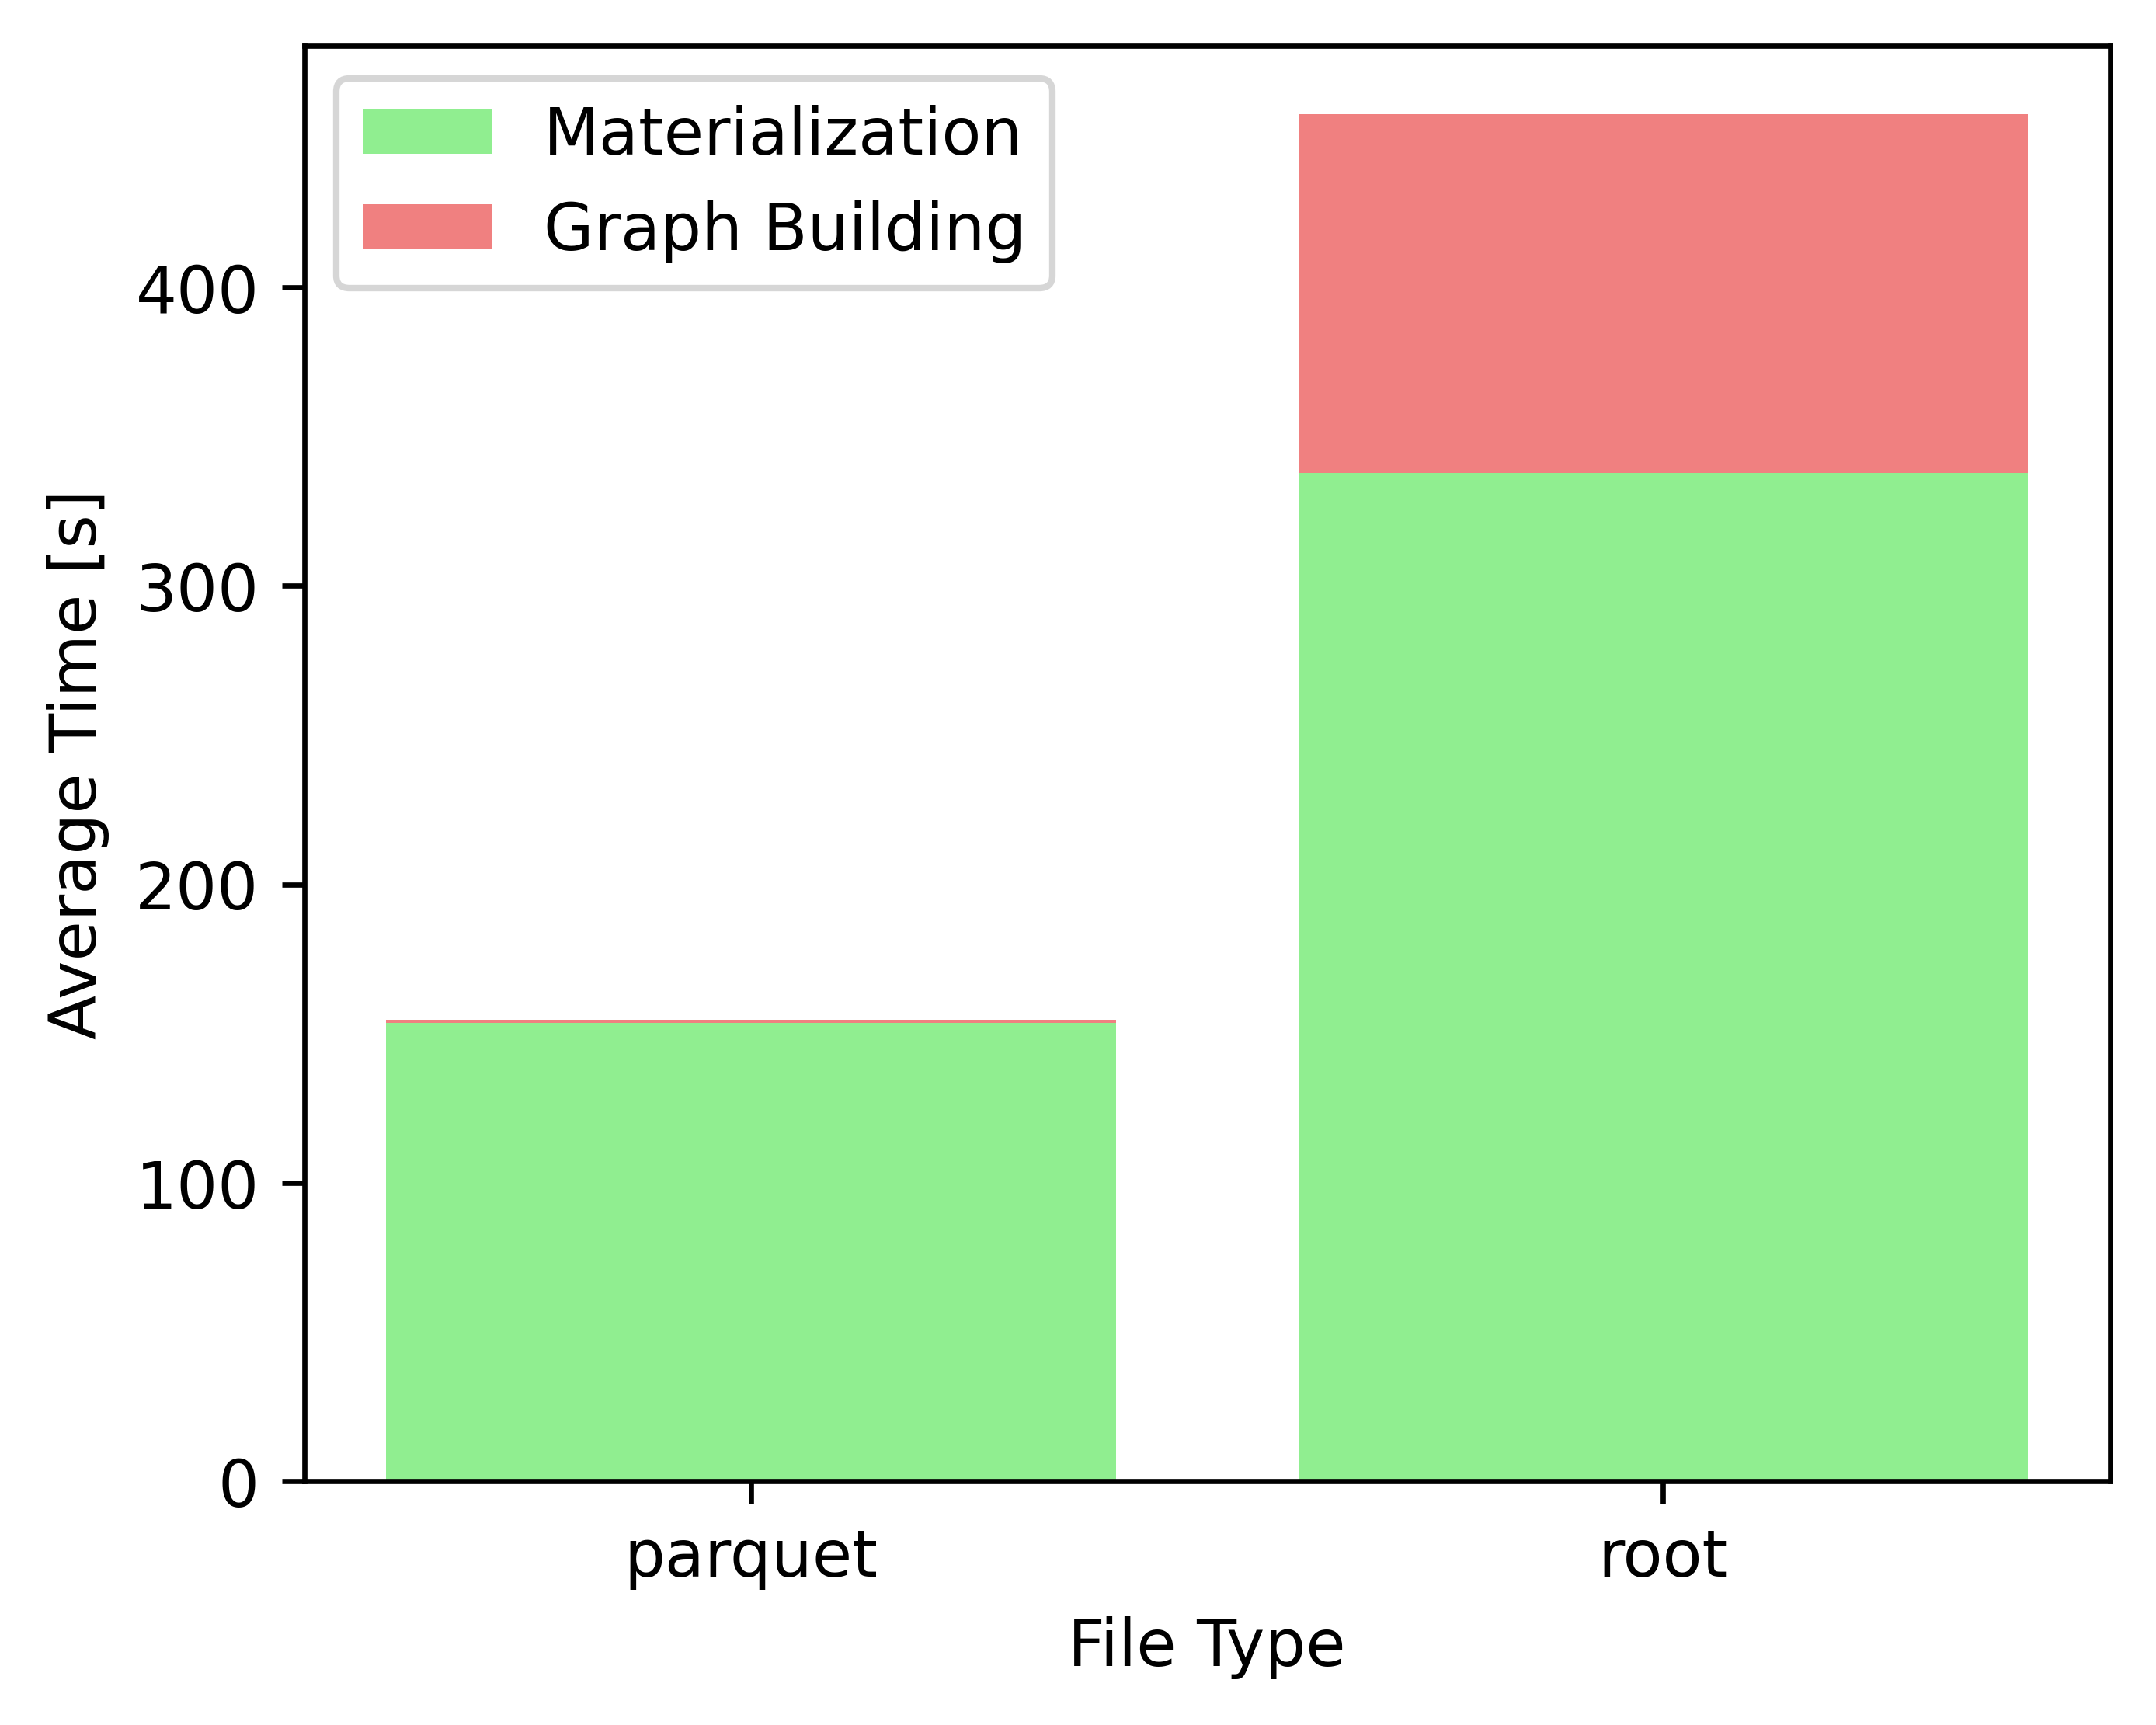

In [8]:
# Plot ingestion time root vs. parquet

df_filtered = df[(df["test_method"].isin(["only_metadata", "iterate_dataloader"])) & (df["column_mode"] == "config")]
grouped = df_filtered.groupby(["file_type", "test_method"])["mean_time"].mean().unstack()
grouped["materialization"] = grouped["iterate_dataloader"] - grouped["only_metadata"]
file_types = grouped.index.tolist()  # ['parquet', 'root']

plt.figure(figsize=(5,4), dpi=600)
plt.bar(file_types, grouped["materialization"], color='lightgreen', label='Materialization')
plt.bar(file_types, grouped["only_metadata"], bottom=grouped["materialization"], color='lightcoral', label='Graph Building')
plt.xlabel('File Type')
plt.ylabel('Average Time [s]')
plt.legend()
plt.savefig("/home/kschmidt/Documents/NEEDLE/plots/benchmarks/root_vs_parquet.png")
plt.show()

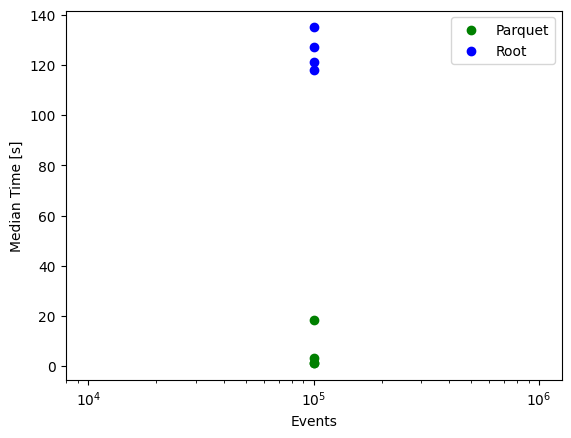

: 

In [ ]:
def plot_same_events(df: pd.DataFrame, x_column: str = "num_events", y_column: str = "median_time") -> None:
    # df = df[(df["column_mode"] == "one") & (df["file_percentage"] == 100.0)]

    df_parquet = df[df["file_type"] == "parquet"]
    df_root = df[df["file_type"] == "root"]
    
    plt.scatter(df_parquet[x_column], df_parquet[y_column], label="Parquet", c="green")
    plt.scatter(df_root[x_column], df_root[y_column], label="Root", c="blue")
    plt.legend()

plot_same_events(df)
plt.xlabel("Events")
plt.ylabel("Median Time [s]")
plt.xscale("log")
plt.show()

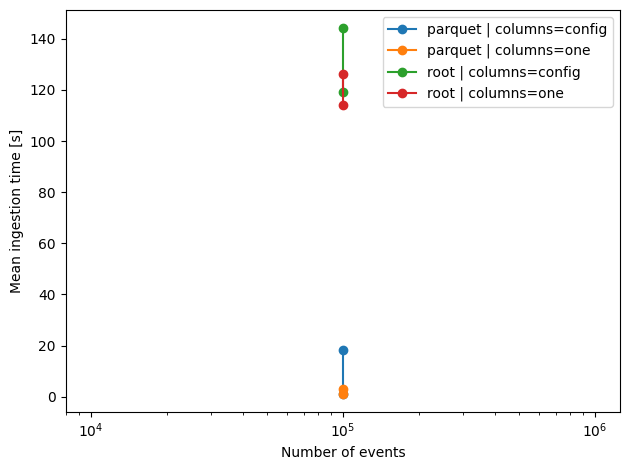

: 

In [ ]:
def plot_ingestion_speed(df: pd.DataFrame):
    fig, ax = plt.subplots()

    for (file_type, column_mode), g in df.groupby(["file_type", "column_mode"]):
        g = g.sort_values("num_events")

        label = f"{file_type} | columns={column_mode}"
        plt.plot(
            g["num_events"],
            g["mean_time"],
            marker="o",
            label=label,
        )

    plt.xlabel("Number of events")
    plt.ylabel("Mean ingestion time [s]")
    plt.legend()
    plt.xscale("log")
    plt.tight_layout()
    plt.show()

plot_ingestion_speed(df)

In [ ]:
df_iterate_simple

NameError: name 'df_iterate_simple' is not defined

: 

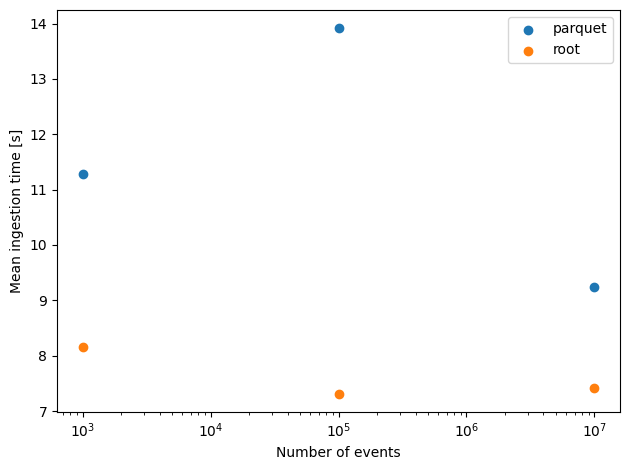

: 

In [ ]:
def plot_ingestion_speed_simple(df: pd.DataFrame):
    fig, ax = plt.subplots()

    df_iterate_simple = df[(df["test_method"] == "iterate_dataloader") & (df["file_percentage"] == 100.0) & (df["column_mode"] == "config")]

    for file_type, g in df_iterate_simple.groupby("file_type"):
        plt.scatter(
            g["num_events"],
            g["median_time"],
            marker="o",
            label=file_type,
        )

    plt.xlabel("Number of events")
    plt.ylabel("Mean ingestion time [s]")
    plt.legend()
    plt.xscale("log")
    plt.tight_layout()
    plt.show()

plot_ingestion_speed_simple(df)

In [ ]:
import sys

sys.path.append("../..")
from test_root_vs_parquet import BenchmarkUtility

FAIR_UNIVERSE_DATA = "/ceph/kschmidt/needle/fair_universe/input_data/train/data/data.parquet"

: 

In [ ]:
BenchmarkUtility.get_files(0.23, [FAIR_UNIVERSE_DATA])

['/ceph/kschmidt/needle/fair_universe/input_data/train/data/data.parquet']

: 

: 